In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langgraph.graph import add_messages
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict, Literal, Annotated
from dotenv import load_dotenv
import operator
from pydantic import BaseModel, Field
load_dotenv()

True

In [2]:
model = ChatGroq(model="llama-3.3-70b-versatile")

In [3]:
class JokeState(TypedDict):
    topic: str
    joke: str 
    explanation: str 

In [8]:
def generate_joke(state: JokeState):
    prompt = f"generate a one line joke on the topic {state['topic']}"
    response = model.invoke(prompt).content
    return {'joke': response} 

In [51]:
import time
def generate_explanation(state: JokeState):
    prompt= f"write an one line explanation for the joke - {state['joke']}"
    response = model.invoke(prompt).content
    return {'explanation': response}

In [52]:
checkpointer = InMemorySaver()
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)
workflow = graph.compile(checkpointer=checkpointer)

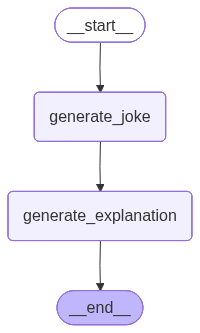

In [7]:
workflow

In [11]:
config1 = {'configurable': {'thread_id': 1}}
response = workflow.invoke({'topic': 'pizza'}, config=config1)
response

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty.',
 'explanation': 'This joke is a play on words, using "crusty" to describe both the pizza\'s bad mood and its crust, creating a humorous pun.'}

In [12]:
workflow.get_state(config=config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty.', 'explanation': 'This joke is a play on words, using "crusty" to describe both the pizza\'s bad mood and its crust, creating a humorous pun.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10736e-2cd8-612a-8002-5ae53d60afa7'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-02-11T10:46:13.994272+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10736e-29eb-6aac-8001-6be2f861061e'}}, tasks=(), interrupts=())

In [23]:
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty.', 'explanation': 'This joke is a play on words, using "crusty" to describe both the pizza\'s bad mood and its crust, creating a humorous pun.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10736e-2cd8-612a-8002-5ae53d60afa7'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-02-11T10:46:13.994272+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10736e-29eb-6aac-8001-6be2f861061e'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty.'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10736e-29eb-6aac-8001-6be2f861061e'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, create

In [37]:
from datetime import datetime, timedelta
def printWorkflow(pipeline, _config):
    snapshots = list(pipeline.get_state_history(config=_config))
    for snapshot in reversed(snapshots):
        metadata = snapshot.metadata
        step = metadata.get('step')
        if snapshot.created_at:
            # 1. Parse UTC string (removes 'Z' or offset if present)
            utc_time = datetime.fromisoformat(snapshot.created_at.replace("Z", "+00:00"))
            
            # 2. Manual conversion to IST (+5:30)
            ist_time = utc_time + timedelta(hours=5, minutes=30)
            
            # 3. Format with AM/PM
            formatted_time = ist_time.strftime("%d %b, %I:%M %p")
        else:
            formatted_time = "N/A"
            
        checkId = snapshot.config.get('configurable').get('checkpoint_id')
        print(f'Start... {step}')
        print(f'TimeStamp: {formatted_time}')
        print(f'Checkpoint Id - {checkId}')
        for key, value in snapshot.values.items():
            print(f"{key} : {value}")
    
        print("#"*20)
        print("\n\n")

In [38]:
printWorkflow(workflow, config1)

Start... -1
TimeStamp: 11 Feb, 04:16 PM
Checkpoint Id - 1f10736e-2796-6d4c-bfff-896e6e01df72
####################



Start... 0
TimeStamp: 11 Feb, 04:16 PM
Checkpoint Id - 1f10736e-27a0-6860-8000-2a3ebe132e3f
topic : pizza
####################



Start... 1
TimeStamp: 11 Feb, 04:16 PM
Checkpoint Id - 1f10736e-29eb-6aac-8001-6be2f861061e
topic : pizza
joke : Why was the pizza in a bad mood? Because it was feeling a little crusty.
####################



Start... 2
TimeStamp: 11 Feb, 04:16 PM
Checkpoint Id - 1f10736e-2cd8-612a-8002-5ae53d60afa7
topic : pizza
joke : Why was the pizza in a bad mood? Because it was feeling a little crusty.
explanation : This joke is a play on words, using "crusty" to describe both the pizza's bad mood and its crust, creating a humorous pun.
####################



Start... 3
TimeStamp: 11 Feb, 04:34 PM
Checkpoint Id - 1f107397-6ce8-6462-8003-7e02cc5095db
topic : pizza
joke : Why was the pizza in a bad mood? Because it was feeling a little crusty.
explanatio

In [34]:
config2 = {'configurable': {'thread_id': 2}}
workflow.invoke({'topic': 'burger'}, config=config2)


{'topic': 'burger',
 'joke': 'Why did the burger go to therapy, because it was feeling a little "well done" under the pressure.',
 'explanation': 'The joke is a play on words, using the culinary term "well done" to describe a burger\'s emotional state, implying it\'s feeling overwhelmed and "cooked" by the pressure, rather than just being a cooking instruction.'}

In [35]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'burger', 'joke': 'Why did the burger go to therapy, because it was feeling a little "well done" under the pressure.', 'explanation': 'The joke is a play on words, using the culinary term "well done" to describe a burger\'s emotional state, implying it\'s feeling overwhelmed and "cooked" by the pressure, rather than just being a cooking instruction.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f107397-f438-6fa2-8002-89045d53ec19'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-02-11T11:04:55.485997+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f107397-f0f0-60ac-8001-65ce0de4602a'}}, tasks=(), interrupts=())

In [ ]:
list(workflow.get_state_history(config2))

In [39]:
printWorkflow(workflow, config2)

Start... -1
TimeStamp: 11 Feb, 04:34 PM
Checkpoint Id - 1f107397-ee6b-64c6-bfff-2b70834d3349
####################



Start... 0
TimeStamp: 11 Feb, 04:34 PM
Checkpoint Id - 1f107397-ee71-651a-8000-03770506b865
topic : burger
####################



Start... 1
TimeStamp: 11 Feb, 04:34 PM
Checkpoint Id - 1f107397-f0f0-60ac-8001-65ce0de4602a
topic : burger
joke : Why did the burger go to therapy, because it was feeling a little "well done" under the pressure.
####################



Start... 2
TimeStamp: 11 Feb, 04:34 PM
Checkpoint Id - 1f107397-f438-6fa2-8002-89045d53ec19
topic : burger
joke : Why did the burger go to therapy, because it was feeling a little "well done" under the pressure.
explanation : The joke is a play on words, using the culinary term "well done" to describe a burger's emotional state, implying it's feeling overwhelmed and "cooked" by the pressure, rather than just being a cooking instruction.
####################





In [43]:
config3 = {'configurable': {'thread_id': 3}}
response = workflow.invoke({'topic': 'fault-tolerance'}, config=config3)
response

KeyboardInterrupt: 

In [45]:
printWorkflow(workflow, config3)

Start... -1
TimeStamp: 11 Feb, 04:39 PM
Checkpoint Id - 1f1073a2-58c6-6438-bfff-4e9d2d39b62f
####################



Start... 0
TimeStamp: 11 Feb, 04:39 PM
Checkpoint Id - 1f1073a2-58c9-64ee-8000-3823a0ddb96d
topic : fault-tolerance
####################



Start... 1
TimeStamp: 11 Feb, 04:39 PM
Checkpoint Id - 1f1073a2-5abd-6f52-8001-cf6dbf52157d
topic : fault-tolerance
joke : Why did the fault-tolerant system go to therapy? Because it was struggling to cope with all the errors in its life.
####################





In [48]:
workflow.invoke(None, config={'configurable': {'thread_id': 3, 'checkpoint_id': '1f1073a2-5abd-6f52-8001-cf6dbf52157d'}})

{'topic': 'fault-tolerance',
 'joke': 'Why did the fault-tolerant system go to therapy? Because it was struggling to cope with all the errors in its life.',
 'explanation': 'This joke plays on the double meaning of "errors" as both technical glitches in a system and personal mistakes, to humorously describe a fault-tolerant system seeking therapy to deal with its emotional struggles.'}

In [49]:
printWorkflow(workflow, config3)

Start... -1
TimeStamp: 11 Feb, 04:39 PM
Checkpoint Id - 1f1073a2-58c6-6438-bfff-4e9d2d39b62f
####################



Start... 0
TimeStamp: 11 Feb, 04:39 PM
Checkpoint Id - 1f1073a2-58c9-64ee-8000-3823a0ddb96d
topic : fault-tolerance
####################



Start... 1
TimeStamp: 11 Feb, 04:39 PM
Checkpoint Id - 1f1073a2-5abd-6f52-8001-cf6dbf52157d
topic : fault-tolerance
joke : Why did the fault-tolerant system go to therapy? Because it was struggling to cope with all the errors in its life.
####################



Start... 2
TimeStamp: 11 Feb, 04:43 PM
Checkpoint Id - 1f1073aa-cf75-68b0-8002-218185f7278a
topic : fault-tolerance
joke : Why did the fault-tolerant system go to therapy? Because it was struggling to cope with all the errors in its life.
explanation : This joke plays on the double meaning of "errors" as both technical glitches in a system and personal mistakes, to humorously describe a fault-tolerant system seeking therapy to deal with its emotional struggles.
##############

In [53]:
config4 = {'configurable': {'thread_id': 4}}
inputs = {'topic': 'Work Life Balance'}

for event in workflow.stream(inputs, config4, stream_mode="updates"):
    for node_name, state_update in event.items():
        print(f"--- Currently Executing: {node_name} ---")
        print(f"State Change: {state_update}")

--- Currently Executing: generate_joke ---
State Change: {'joke': 'I\'ve finally achieved work-life balance, which is just code for "I\'m now equally bad at my job and my personal life."'}
--- Currently Executing: generate_explanation ---
State Change: {'explanation': "This joke humorously suggests that achieving work-life balance doesn't necessarily mean excelling in both areas, but rather being equally unproductive and struggling in both professional and personal aspects of life."}


In [55]:
printWorkflow(workflow, config4)

Start... -1
TimeStamp: 11 Feb, 04:48 PM
Checkpoint Id - 1f1073b5-3f95-6ee2-bfff-5ee24b185c9b
####################



Start... 0
TimeStamp: 11 Feb, 04:48 PM
Checkpoint Id - 1f1073b5-3f9c-6576-8000-2a4d8822e73b
topic : Work Life Balance
####################



Start... 1
TimeStamp: 11 Feb, 04:48 PM
Checkpoint Id - 1f1073b5-4217-6440-8001-c2f71054d573
topic : Work Life Balance
joke : I've finally achieved work-life balance, which is just code for "I'm now equally bad at my job and my personal life."
####################



Start... 2
TimeStamp: 11 Feb, 04:48 PM
Checkpoint Id - 1f1073b5-461a-6056-8002-754c93782491
topic : Work Life Balance
joke : I've finally achieved work-life balance, which is just code for "I'm now equally bad at my job and my personal life."
explanation : This joke humorously suggests that achieving work-life balance doesn't necessarily mean excelling in both areas, but rather being equally unproductive and struggling in both professional and personal aspects of life.


In [57]:
workflow.update_state({'configurable': {'thread_id': 4, 'checkpoint_id': '1f1073b5-3f9c-6576-8000-2a4d8822e73b', 'checkpoint_ns': ''}}, {'topic': 'work from home'})

{'configurable': {'thread_id': '4',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1073c4-7aad-685e-8001-2db06b6fb86e'}}

In [59]:
for event in workflow.stream(None, {'configurable': {'thread_id': 4,'checkpoint_id': '1f1073c4-7aad-685e-8001-2db06b6fb86e' }}, stream_mode="updates"):
    for node_name, state_update in event.items():
        print(f"--- Currently Executing: {node_name} ---")
        print(f"State Change: {state_update}")

--- Currently Executing: generate_joke ---
State Change: {'joke': "I'm not lazy, I'm just on energy-saving mode, which is a standard setting when you work from home."}
--- Currently Executing: generate_explanation ---
State Change: {'explanation': 'This joke humorously excuses one\'s laziness by comparing their idle state to a computer\'s "energy-saving mode", poking fun at the flexibility and lack of structure that can come with working from home.'}


In [60]:
printWorkflow(workflow, config4)

Start... -1
TimeStamp: 11 Feb, 04:48 PM
Checkpoint Id - 1f1073b5-3f95-6ee2-bfff-5ee24b185c9b
####################



Start... 0
TimeStamp: 11 Feb, 04:48 PM
Checkpoint Id - 1f1073b5-3f9c-6576-8000-2a4d8822e73b
topic : Work Life Balance
####################



Start... 1
TimeStamp: 11 Feb, 04:48 PM
Checkpoint Id - 1f1073b5-4217-6440-8001-c2f71054d573
topic : Work Life Balance
joke : I've finally achieved work-life balance, which is just code for "I'm now equally bad at my job and my personal life."
####################



Start... 2
TimeStamp: 11 Feb, 04:48 PM
Checkpoint Id - 1f1073b5-461a-6056-8002-754c93782491
topic : Work Life Balance
joke : I've finally achieved work-life balance, which is just code for "I'm now equally bad at my job and my personal life."
explanation : This joke humorously suggests that achieving work-life balance doesn't necessarily mean excelling in both areas, but rather being equally unproductive and struggling in both professional and personal aspects of life.
